First we gonna run decision tree without handling class imbalance
Then handle class imbalance and give decision through decision tree

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('diabetes.csv')

In [ ]:
from sklearn.model_selection import train_test_split

X=df.drop('Outcome', axis=1)
Y=df['Outcome']

X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, random_state=24)
print("Original dataset split into train and test set")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

Original dataset split into train and test set
X_train shape: (614, 8)
X_test shape: (154, 8)
Y_train shape: (614,)
Y_test shape: (154,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model_no_balancing = DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model_no_balancing.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

# Plot decision tree

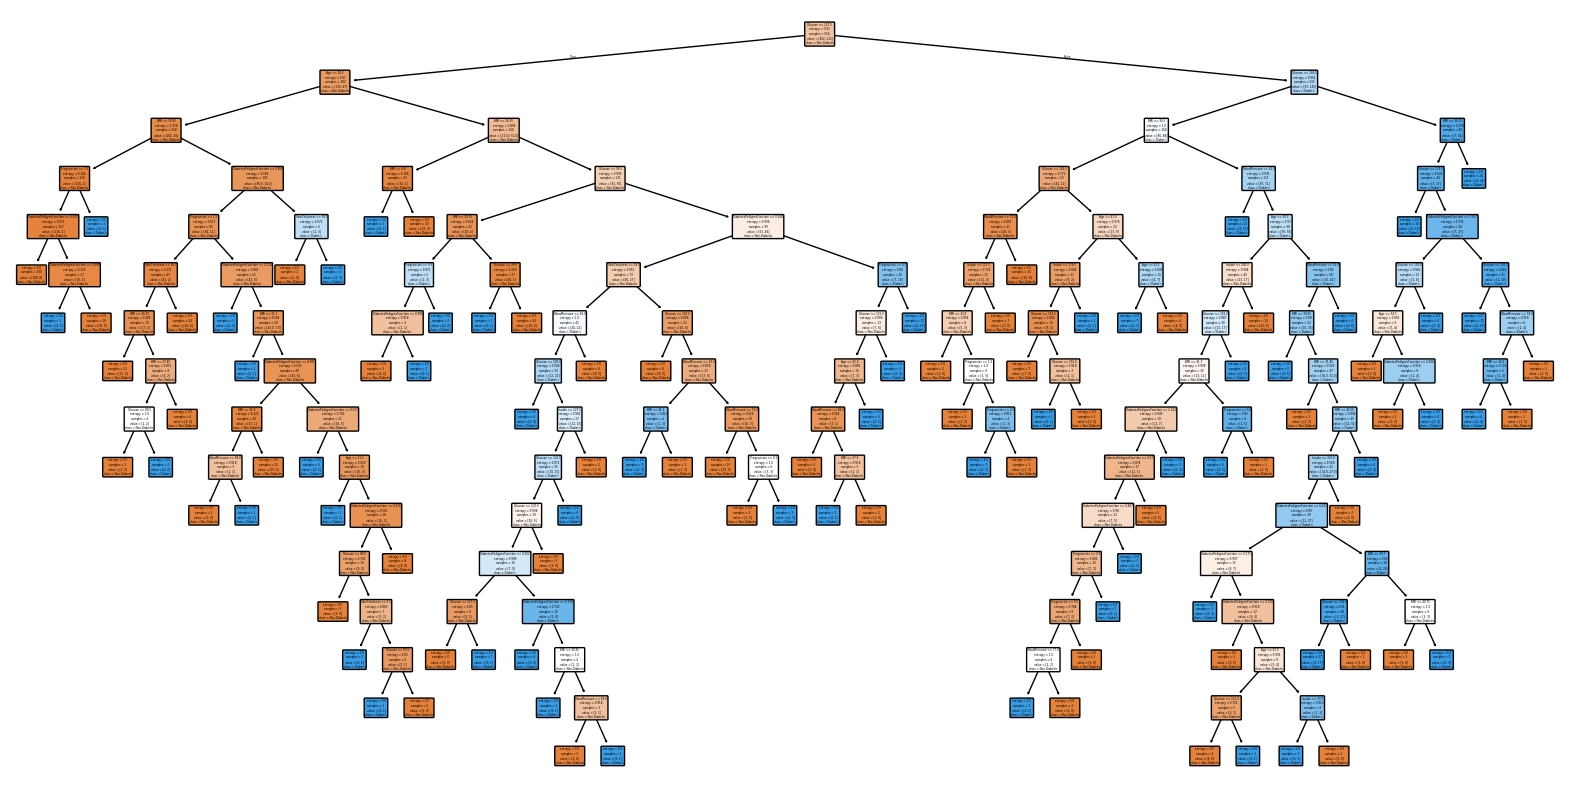

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    dt_model_no_balancing,
    feature_names=X_train.columns,
    class_names=['Non-Diabetic', 'Diabetic'],
    filled=True,
    rounded=True,
    fontsize=2
)
plt.show()

## **Feature Importance**

In [ ]:
importances = dt_model_no_balancing.feature_importances_
fi_df=pd.DataFrame({'feature':X_train.columns, 'importance':importances}).sort_values('importance', ascending=False)
print(fi_df)

                    feature  importance
1                   Glucose    0.353421
5                       BMI    0.186127
6  DiabetesPedigreeFunction    0.129587
7                       Age    0.104951
2             BloodPressure    0.083606
0               Pregnancies    0.071697
4                   Insulin    0.043333
3             SkinThickness    0.027278


# Decision tree without class balance or sorting feature importance

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_no_balancing=dt_model_no_balancing.predict(X_test)

accuracy_no_balancing=dt_model_no_balancing.score(X_test, Y_test)
precision_no_balancing=precision_score(Y_test, y_pred_no_balancing)
recall_no_balancing=recall_score(Y_test, y_pred_no_balancing)
f1_no_balancing=f1_score(Y_test, y_pred_no_balancing)

print(f"Accuracy: {accuracy_no_balancing}")
print(f"Precision: {precision_no_balancing}")
print(f"Recall: {recall_no_balancing}")
print(f"F1 Score: {f1_no_balancing}")

Accuracy: 0.7142857142857143
Precision: 0.62
Recall: 0.5535714285714286
F1 Score: 0.5849056603773585


## After taking three most important features

In [ ]:
from sklearn.model_selection import train_test_split

X=df[['Glucose', 'BMI', 'DiabetesPedigreeFunction']]
Y=df['Outcome']

X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, random_state=42)
print("Original dataset split into train and test set")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

Original dataset split into train and test set
X_train shape: (614, 3)
X_test shape: (154, 3)
Y_train shape: (614,)
Y_test shape: (154,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model_no_balancing = DecisionTreeClassifier(criterion='entropy',random_state=121)
dt_model_no_balancing.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', random_state=121)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_no_balancing=dt_model_no_balancing.predict(X_test)

accuracy_no_balancing=dt_model_no_balancing.score(X_test, Y_test)
precision_no_balancing=precision_score(Y_test, y_pred_no_balancing)
recall_no_balancing=recall_score(Y_test, y_pred_no_balancing)
f1_no_balancing=f1_score(Y_test, y_pred_no_balancing)

print(f"Accuracy: {accuracy_no_balancing}")
print(f"Precision: {precision_no_balancing}")
print(f"Recall: {recall_no_balancing}")
print(f"F1 Score: {f1_no_balancing}")

Accuracy: 0.6948051948051948
Precision: 0.5689655172413793
Recall: 0.6
F1 Score: 0.584070796460177


## Cross Validation
We need to give the full dataset as input instead of train/test split because it itself divides it into k fold and in cross_val_score gives accuracy score. Mean summarizes all accuracies into one.

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(dt_model_no_balancing,X,Y,cv=5).mean()

np.float64(0.688914353620236)

# Class Imbalance Handle and then run models

In [ ]:
from imblearn.over_sampling import SMOTE

smote_sampler = SMOTE(random_state=42)

print("Class distribution before SMOTE:")
print(Y_train.value_counts())

X_train_smote, Y_train_smote = smote_sampler.fit_resample(X_train, Y_train)

print("Class distribution after SMOTE:")
print(Y_train_smote.value_counts())

Class distribution before SMOTE:
Outcome
0    402
1    212
Name: count, dtype: int64
Class distribution after SMOTE:
Outcome
1    402
0    402
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model.fit(X_train_smote, Y_train_smote)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred=dt_model.predict(X_test)

accuracy=dt_model.score(X_test, Y_test)
precision=precision_score(Y_test, y_pred)
recall=recall_score(Y_test, y_pred)
f1=f1_score(Y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.6883116883116883
Precision: 0.5645161290322581
Recall: 0.625
F1 Score: 0.5932203389830508


# Class Imbalance handled using ADASYN

In [ ]:
from imblearn.over_sampling import ADASYN

adasyn_sampler = ADASYN(random_state=42)

print("Class distribution before ADASYN:")
print(Y_train.value_counts())

X_train_ad, Y_train_ad = adasyn_sampler.fit_resample(X_train, Y_train)

print("Class distribution after ADASYN:")
print(Y_train_ad.value_counts())

Class distribution before ADASYN:
Outcome
0    402
1    212
Name: count, dtype: int64
Class distribution after ADASYN:
Outcome
1    404
0    402
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model.fit(X_train_ad, Y_train_ad)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred=dt_model.predict(X_test)

accuracy=dt_model.score(X_test, Y_test)
precision=precision_score(Y_test, y_pred)
recall=recall_score(Y_test, y_pred)
f1=f1_score(Y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.6688311688311688
Precision: 0.5490196078431373
Recall: 0.5
F1 Score: 0.5233644859813084


# Class Imbalance using SMOTE-TOMEK

In [ ]:
from imblearn.combine import SMOTETomek

smote_tomek_sampler = SMOTETomek(random_state=42)

print("Class distribution before SMOTE-Tomek")
print(Y_train.value_counts())

X_train_smt, Y_train_smt = smote_tomek_sampler.fit_resample(X_train, Y_train)

print("Class distribution after ADASYN:")
print(Y_train_smt.value_counts())

Class distribution before SMOTE-Tomek
Outcome
0    402
1    212
Name: count, dtype: int64
Class distribution after ADASYN:
Outcome
1    380
0    380
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model.fit(X_train_smt, Y_train_smt)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred=dt_model.predict(X_test)

accuracy=dt_model.score(X_test, Y_test)
precision=precision_score(Y_test, y_pred)
recall=recall_score(Y_test, y_pred)
f1=f1_score(Y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.6948051948051948
Precision: 0.5918367346938775
Recall: 0.5178571428571429
F1 Score: 0.5523809523809524


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'No Balancing': metrics_no_balancing,
    'SMOTE': metrics_smote,
    'ADASYN': metrics_adasyn,
    'SMOTE-Tomek': metrics_smote_tomek
}).T

print("Comparison of Decision Tree Models with and without Class Imbalance Handling:")
display(comparison_df)

Comparison of Decision Tree Models with and without Class Imbalance Handling:


,Accuracy,Precision,Recall,F1 Score
No Balancing,0.714286,0.620000,0.553571,0.584906
SMOTE,0.688312,0.564516,0.625000,0.593220
ADASYN,0.668831,0.549020,0.500000,0.523364
SMOTE-Tomek,0.694805,0.591837,0.517857,0.552381
